In [2]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.io.fits as fits

# Load data image and header

In [13]:
data_dir = os.getcwd()
files_roll1 = [f for f in os.listdir(data_dir) if f.startswith("host_star_image_roll1")]
files_roll2 = [f for f in os.listdir(data_dir) if f.startswith("host_star_image_roll2")]
print(files_roll1)
print(files_roll2)

roll1 = []
for file in files_roll1:
    roll1.append(fits.getdata(file))
roll1 = np.array(roll1)

roll2 = []
for file in files_roll2:
    roll2.append(fits.getdata(file))
roll2 = np.array(roll2)

['host_star_image_roll1_0.fits']
['host_star_image_roll2_0.fits']


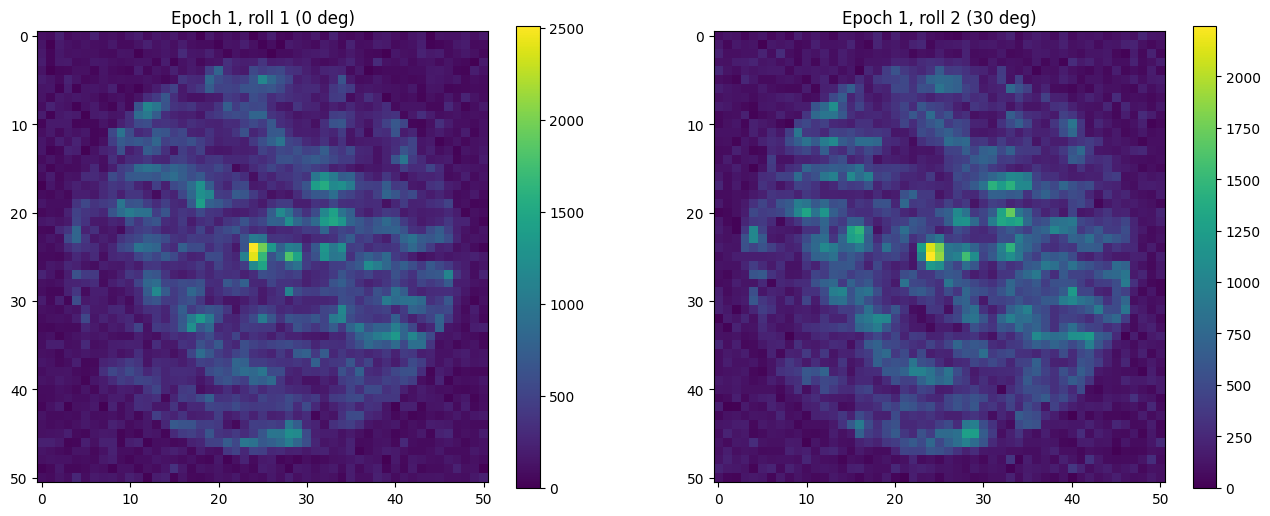

In [14]:
coadd_roll1 = np.mean(roll1, axis = 0)
coadd_roll2 = np.mean(roll2, axis = 0)

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(coadd_roll1)
plt.title('Epoch 1, roll 1 (0 deg)')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 (30 deg)')
plt.imshow(coadd_roll2)
plt.colorbar()

# Roll subtraction and roll combination

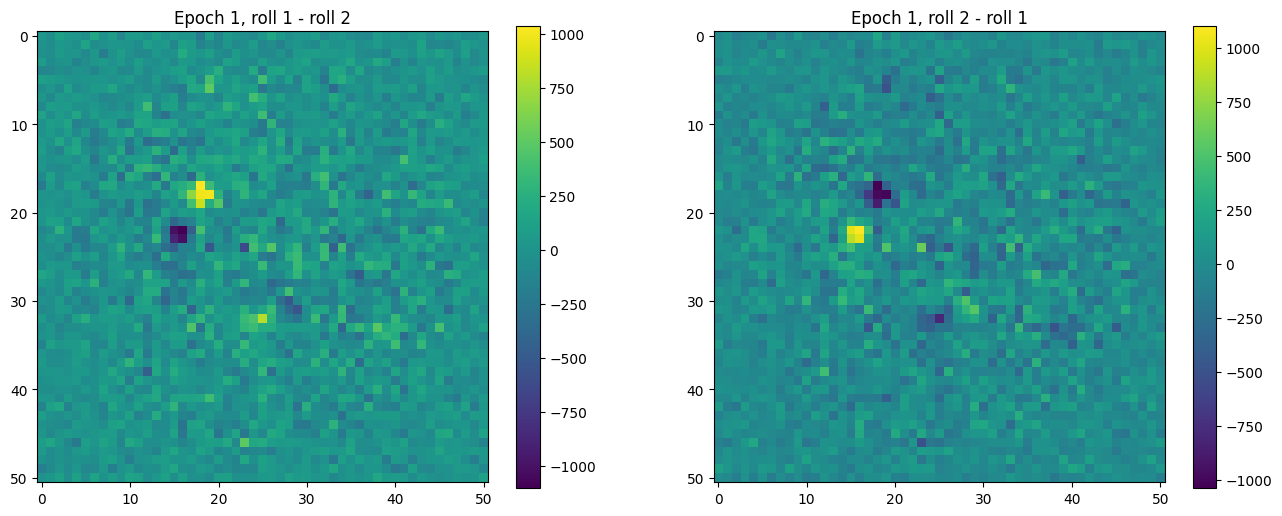

In [15]:
diff1 = coadd_roll1 - coadd_roll2
diff2 = coadd_roll2 - coadd_roll1

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(diff1)
plt.title('Epoch 1, roll 1 - roll 2')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 - roll 1')
plt.imshow(diff2)
plt.colorbar()

In [16]:
import skimage.transform
scistar_coadd_ep1_rolls = [0, 30]
imgwidth = diff2.shape[0]
derot_diff_2 = skimage.transform.rotate(image = diff2,
                                        angle = -scistar_coadd_ep1_rolls[1],
                                        center = (imgwidth // 2, imgwidth // 2),
                                        order = 3, cval = np.nan)
derot_sum = diff1 + derot_diff_2

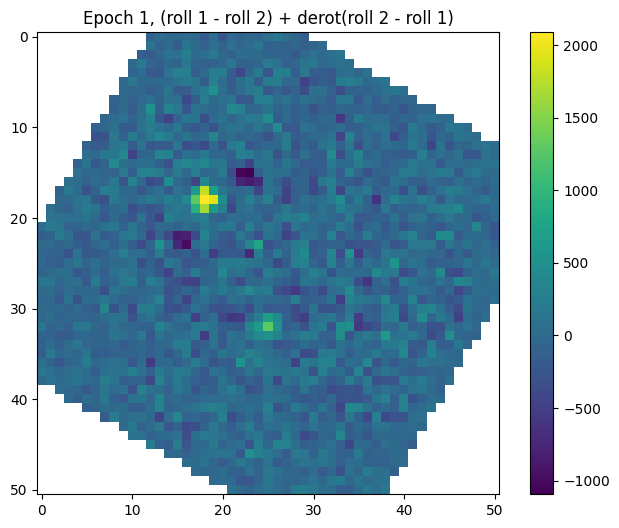

In [17]:
plt.figure(figsize=(8,6))

plt.imshow(derot_sum)

plt.title('Epoch 1, (roll 1 - roll 2) + derot(roll 2 - roll 1)')
plt.colorbar()

## Question 1: How would you estimate the signal-to-noise ratio of this source?

# Reference Differential Imaging

['ref_star_image_0.fits']


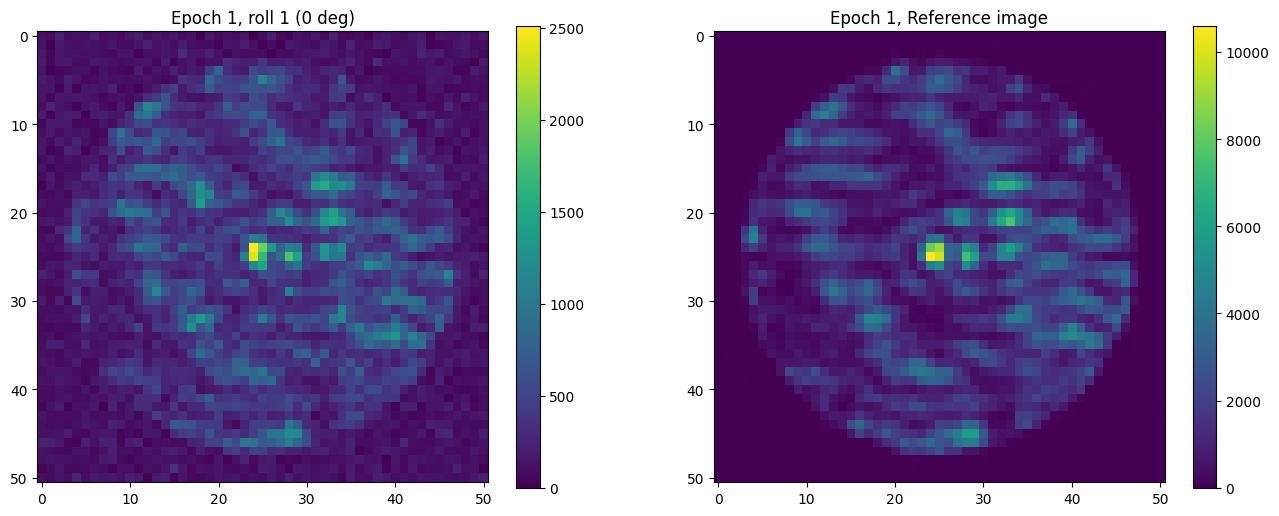

In [20]:
data_dir = os.getcwd()
files_ref = [f for f in os.listdir(data_dir) if f.startswith("ref_star_image")]
print(files_ref)


ref = []
for file in files_ref:
    ref.append(fits.getdata(file))
ref = np.array(ref)

coadd_ref = np.mean(ref, axis = 0)

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(coadd_roll1)
plt.title('Epoch 1, roll 1 (0 deg)')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, Reference image')
plt.imshow(coadd_ref)
plt.colorbar()


In [25]:
count_sum_ratio_roll1 = (np.sum(coadd_ref)
                    / np.sum(coadd_roll1))
count_sum_ratio_roll2 = (np.sum(coadd_ref)
                    / np.sum(coadd_roll2))
print(count_sum_ratio_roll1)
print(count_sum_ratio_roll2)

2.9446029568440872
2.9685687661692763


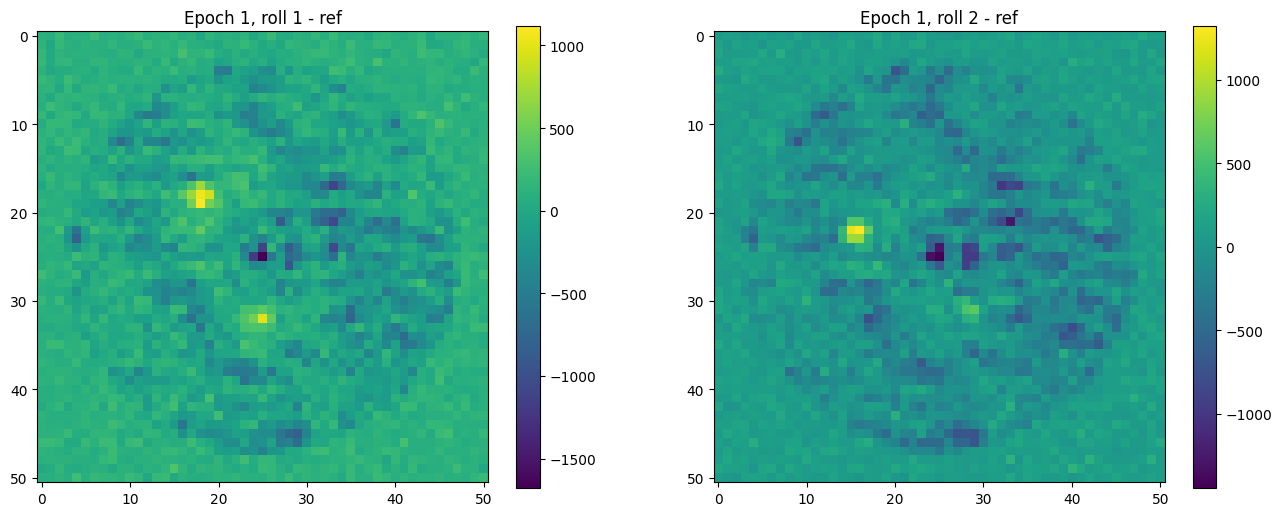

In [28]:
crude_rdi_result_roll1 = (coadd_roll1
                    - coadd_ref / count_sum_ratio_roll1)
crude_rdi_result_roll2 = (coadd_roll2
                    - coadd_ref / count_sum_ratio_roll2)

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(crude_rdi_result_roll1)
plt.title('Epoch 1, roll 1 - ref')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 - ref')
plt.imshow(crude_rdi_result_roll2)
plt.colorbar()

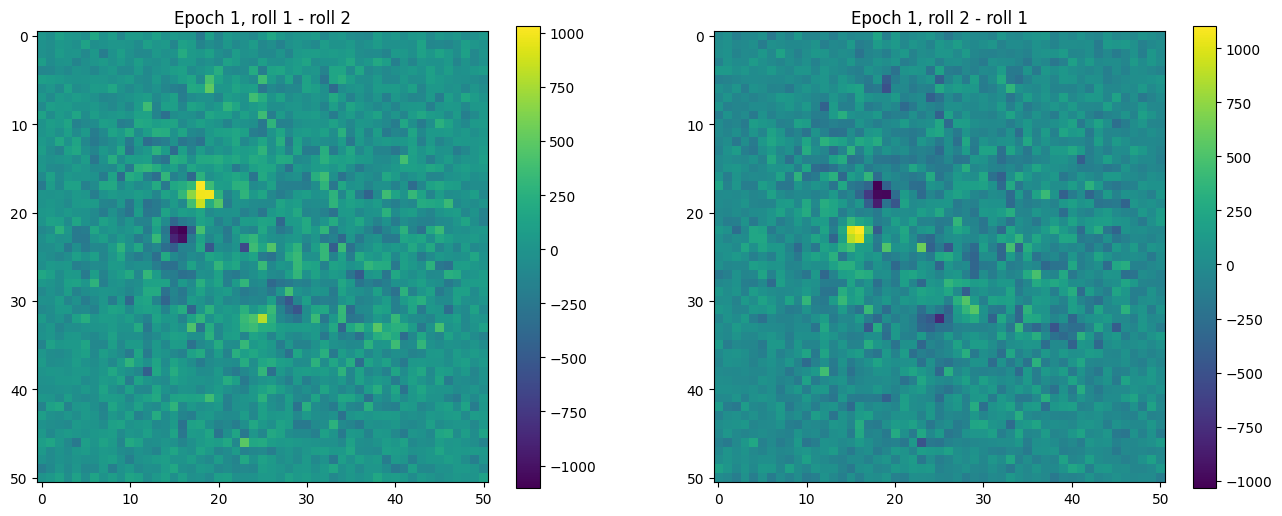

In [29]:
adi_rdi_1 = crude_rdi_result_roll1 - crude_rdi_result_roll2
adi_rdi_2 = crude_rdi_result_roll2 - crude_rdi_result_roll1

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(adi_rdi_1)
plt.title('Epoch 1, roll 1 - roll 2')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 - roll 1')
plt.imshow(adi_rdi_2)
plt.colorbar()

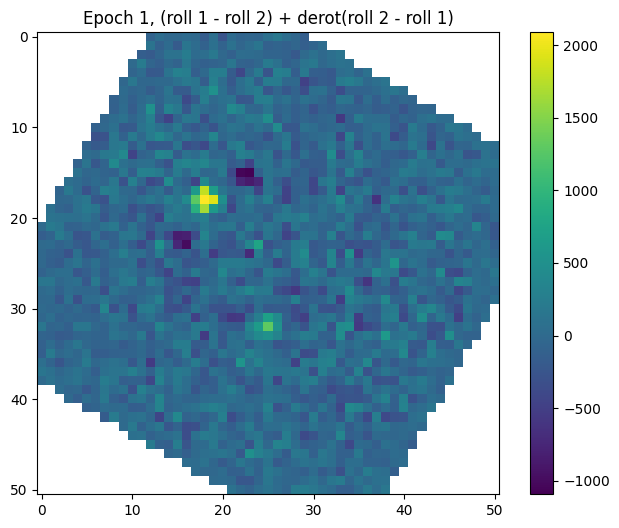

In [30]:
cistar_coadd_ep1_rolls = [0, 30]
imgwidth = diff2.shape[0]
derot_adi_rdi_2 = skimage.transform.rotate(image = adi_rdi_2,
                                        angle = -scistar_coadd_ep1_rolls[1],
                                        center = (imgwidth // 2, imgwidth // 2),
                                        order = 3, cval = np.nan)
derot_sum_adi_rdi = adi_rdi_1 + derot_adi_rdi_2

plt.figure(figsize=(8,6))

plt.imshow(derot_sum_adi_rdi)

plt.title('Epoch 1, (roll 1 - roll 2) + derot(roll 2 - roll 1)')
plt.colorbar()


Peak col = 18, peak row = 18
Sum in 3 x 3 box = 6253.96 electron


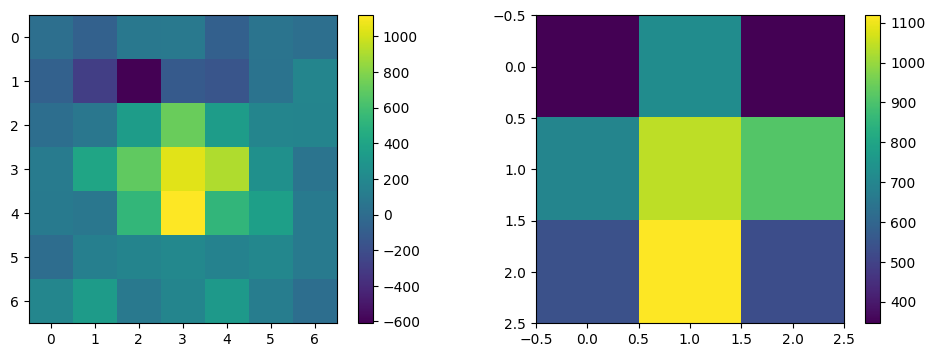

In [71]:
# Photometry
processed_image = crude_rdi_result_roll1
img_width = processed_image.shape[0]
phot_box_width = 3

src_peak_row = np.nanargmax(np.ravel(processed_image)) // img_width -1
src_peak_col = np.nanargmax(np.ravel(processed_image)) % img_width

phot_box_sum = np.sum(processed_image[src_peak_row - phot_box_width // 2 : 
                                    src_peak_row + phot_box_width // 2 + 1,
                                    src_peak_col - phot_box_width // 2 : 
                                    src_peak_col + phot_box_width // 2 + 1]) * u.electron

print("Peak col = {:d}, peak row = {:d}".format(src_peak_col, src_peak_row))
print("Sum in {:d} x {:d} box = {:.2f}".format(phot_box_width, phot_box_width, phot_box_sum))

plt.figure(figsize=(12, 4))

plt.subplot(121)
plot_box_width = 7
plt.imshow(processed_image[src_peak_row - plot_box_width // 2 : 
                         src_peak_row + plot_box_width // 2 + 1,
                         src_peak_col - plot_box_width // 2 : 
                         src_peak_col + plot_box_width // 2 + 1])
_ = plt.colorbar()

plt.subplot(122)
plt.imshow(processed_image[src_peak_row - phot_box_width // 2 : 
                         src_peak_row + phot_box_width // 2 + 1,
                         src_peak_col - phot_box_width // 2 : 
                         src_peak_col + phot_box_width // 2 + 1])
_ = plt.colorbar()

B.g. estimate = -75.177 electron
B.g.-subtracted aperture sum = 6930.557 electron


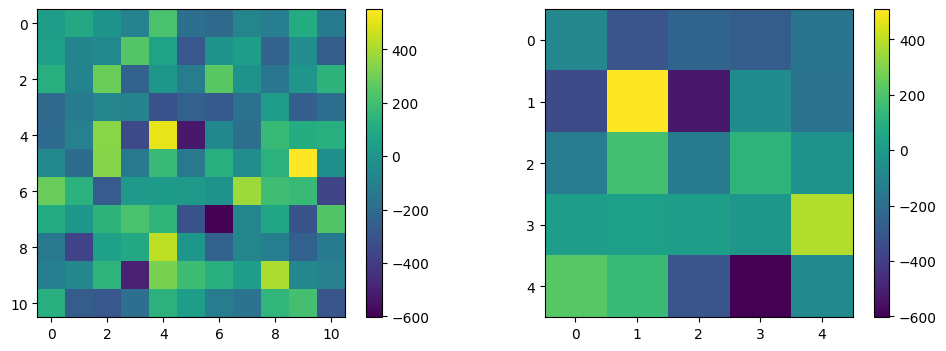

In [72]:
# Estimate the background count rate by taking a box away from the source, but at a similar angular separation from the star
bg_samp_col = 35
bg_samp_row = 25
bg_box_width = 5
bg_est = np.median(derot_sum_adi_rdi[bg_samp_row - bg_box_width//2 : 
                                 bg_samp_row + bg_box_width // 2 + 1,
                                 bg_samp_col - bg_box_width//2 : 
                                 bg_samp_col + bg_box_width // 2 + 1]) * u.electron

phot_box_sum_bgsub = phot_box_sum - bg_est * (phot_box_width * phot_box_width)

print("B.g. estimate = {:.3f}".format(bg_est))
print("B.g.-subtracted aperture sum = {:.3f}".format(phot_box_sum_bgsub))

plt.figure(figsize=(12, 4))

plt.subplot(121)
plot_box_width = 10
plt.imshow(derot_sum_adi_rdi[bg_samp_row - plot_box_width//2 : 
                         bg_samp_row + plot_box_width // 2 + 1,
                         bg_samp_col - plot_box_width//2 : 
                         bg_samp_col + plot_box_width // 2 + 1])
_ = plt.colorbar()

plt.subplot(122)
plt.imshow(derot_sum_adi_rdi[bg_samp_row - bg_box_width//2 : 
                         bg_samp_row + bg_box_width // 2 + 1,
                         bg_samp_col - bg_box_width//2 : 
                         bg_samp_col + bg_box_width // 2 + 1])
_ = plt.colorbar()

['host_star_PSF_0.fits']
25 25
Peak col = 25, peak row = 25
Star PSF photon count rate in 3 x 3 box = 48767.00 ph / s


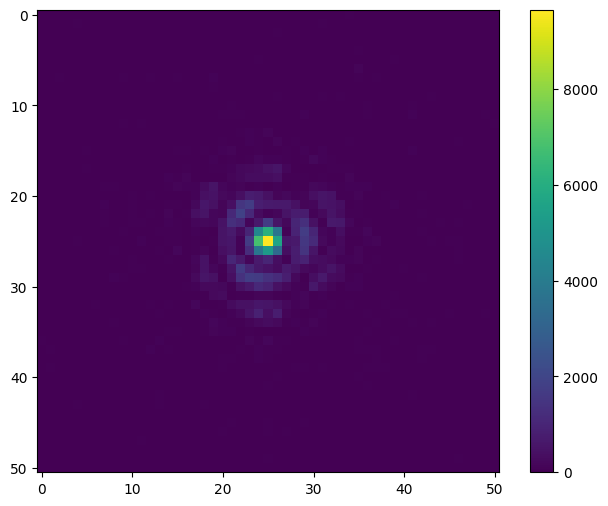

In [73]:
# Measure the star PSF model count rate in the same 3x3 box

data_dir = os.getcwd()
files_PSF = [f for f in os.listdir(data_dir) if f.startswith("host_star_PSF")]
print(files_PSF)


PSF = []
for file in files_PSF:
    PSF.append(fits.getdata(file))
PSF = np.array(PSF)

host_star_PSF = np.mean(PSF, axis = 0)

host_star_PSF_width = host_star_PSF.shape[0]

star_peak_row = np.nanargmax(np.ravel(host_star_PSF)) // host_star_PSF_width
star_peak_col = np.nanargmax(np.ravel(host_star_PSF)) % host_star_PSF_width
print(star_peak_col, star_peak_row)

star_phot_box_sum = (np.sum(host_star_PSF[star_peak_row - phot_box_width//2 : 
                                         star_peak_row + phot_box_width // 2 + 1,
                                         star_peak_col - phot_box_width//2 : 
                                         star_peak_col + phot_box_width // 2 + 1])
                     * u.photon / u.second)

print("Peak col = {:d}, peak row = {:d}".format(star_peak_col, star_peak_row))
print("Star PSF photon count rate in {:d} x {:d} box = {:.2f}".format(
      phot_box_width, phot_box_width, star_phot_box_sum))

plt.figure(figsize=(8, 6))
plt.imshow(host_star_PSF)
plt.colorbar()

In [74]:
planet_phot_box_sum = (phot_box_sum / 1)/ u.electron * u.photon / u.second#(det_qe * pc_loss * psf_atten)) / tot_inttime
print("Planet PSF photon count rate in {:d} x {:d} box = {:.2E}".format(
      phot_box_width, phot_box_width, planet_phot_box_sum))

planet_flux_ratio = (planet_phot_box_sum / 10000) / (star_phot_box_sum / 0.01)  /0.9
print("Measured planet flux ratio = {:.3E}".format(planet_flux_ratio))

true_flux_ratio = 10**((8-25)/2.5)  # taken from scene simulation inputs
error_frac = (planet_flux_ratio - true_flux_ratio) / true_flux_ratio
print("Measured flux ratio = {:.2E}\nTrue flux ratio = {:.2E}\nRelative error = {:.1f}%".format(
      planet_flux_ratio, true_flux_ratio, 100 * error_frac))

Planet PSF photon count rate in 3 x 3 box = 6.25E+03 ph / s
Measured planet flux ratio = 1.425E-07
Measured flux ratio = 1.42E-07
True flux ratio = 1.58E-07
Relative error = -10.1%


In [ ]:
# TARGET STAR PROCESSING
# BY THE BOOK : 
# data_1 = -np.log ( 1 - data_1 / ( numfrm * np.exp ( - n_thresholdfactor * sigma_readnoise / gain_trg ) ) )
# data_1        will be called "nobs"          in Nemati equations
# numfrm        will be called "nfr"           in Nemati equations
# tau_threshold will be called "threshold" (t) in Nemati equations
# gain_trg      will be called "gain"      (g) in Nemati equations
# The following steps were performed for each pointing of each
#   noisy target data cube at both -11 degrees and +11 degrees:
# • Apply threshold to each frame of data cube. We chose a threshold factor of 5 
#   (5 times read noise, note that read noise can be found in the FITS header) 
#   in this case. Binary images were obtained in output;
# • Co-add frames in data cube along the temporal dimension;
# • Correct for the coincidence and threshold losses;
# • Background correction is performed by averaging a subset of 36 pixels in the
#   corner of the image;
# • Normalization by the frame exposure time to obtain an image in count/sec.

In [ ]:
psf_peak_map = fits.getdata(data_dir + '/OS6_HLC_PSF_peak_map.fits')
psf_peak_map_hdr = fits.getheader(data_dir + '/OS6_HLC_PSF_peak_map.fits')

#detector_pixel_size = 0.42 # dimensions of: [lambda_central_wavelength / Roman_diameter]
pixscale_ratio = (21.8/49.3) / psf_peak_map_hdr['PIXSIZE']
print(pixscale_ratio)
print(psf_peak_map_hdr['PIXSIZE'])
print((21.8/49.3))

peak_map_width = psf_peak_map.shape[0]

src_peak_map_col = (peak_map_width // 2 
                    + int(np.round((src_peak_col - img_width // 2)
                    * pixscale_ratio)))
src_peak_map_row = (peak_map_width // 2
                    + int(np.round((src_peak_row - img_width // 2)
                    * pixscale_ratio)))

print("Source position in peak map: {:}, {:}".format(src_peak_map_col, src_peak_map_row))

psf_atten = psf_peak_map[src_peak_map_row, src_peak_map_col] / np.max(psf_peak_map)
print("Relative PSF attenuation: {:.2f}".format(psf_atten))

4.421906693711968
0.1
0.4421906693711968
Source position in peak map: 69, 69
Relative PSF attenuation: 0.94
